<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 11</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>



<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 11</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 11_01: Markov Prozesse 
- **Aufgabe 11_02: Integration mit MCMC**
- Aufgabe 11_03: Radom Walks

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline"> Integration mit Markov Chain Monte Carlo</td>


In dieser Aufgabe wollen wir die zwei-dimensionale Funktion
\begin{equation}
f(x,y) = (x^2+y^2) \cdot e^{-x^2-y^2}
\end{equation}

betrachten, welche über den gesamten Bereich $\mathbb{R}^2$ integriert werden soll, d.h. wir wollen das Integral
\begin{equation}
I = \int\limits_{\mathbb{R}^2} f(x,y)\; \text{d}x\, \text{d}y
\end{equation}
berechnen. 

Visualisiert sieht die Funktion wie folgt aus:

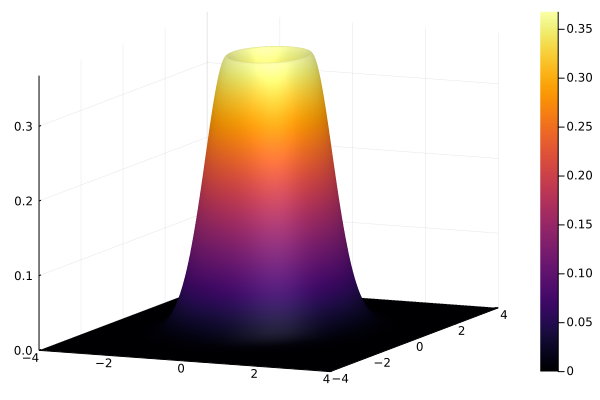

In [1]:
using Plots

f(x,y) = (x^2+y^2)*exp(-x^2-y^2)

x_range = -4:0.01:4
y_range = -4:0.01:4
z_range = [f(x,y) for x in x_range, y in y_range]

surface(x_range, y_range, z_range)

Letzte Woche haben wir in Aufgabe 10.2 bereits gesehen, dass wir das Integral besonders gut durch ein sogenanntes **importance sampling** annähern können. Dabei generieren wir zufällige Koordinaten $(x,y)$ nicht gleichverteilt, sondern gemäss einer Verteilung $P(x,y)$, die der zu integrierenden Funktion ähnelt (und welche wir leicht erzeugen können). Es gilt dann:
\begin{equation}
I = \int\limits_{\mathbb{R}^2} f(x,y)\; \text{d}x\, \text{d}y = \int\limits_{\mathbb{R}^2} \frac{f(x,y)}{P(x,y)} P(x,y)\; \text{d}x\, \text{d}y \approx \frac{1}{N}\sum\limits_{i=1}^{N}\frac{f(x_i,y_i)}{P(x_i,y_i)} \,,
\end{equation}
wobei die $(x_i,y_i)$ in der Annäherung im letzten Term $P$-verteilte Koordinaten seien. 

Als Verteilung $P(x,y)$ für die zu integrierende Funktion $f(x,y)$ können wir etwa eine Normalverteilung der Form
\begin{equation*}
P(x,y) = \frac{1}{\pi}e^{-x^2-y^2},
\end{equation*}
wählen.

### a) Implementation der Markov-Kette

In dieser Aufgabe wollen wir zur Erzeugung der $P$-verteilten Zufallskoordinaten $(x_i, y_i)$ eine **Markov-Kette** verwenden welche wir mit dem **Metropolis-Algorithmus** erzeugen. Implementieren Sie eine Funktion die die Markov-Kette mit Hilfe des Metropolis Algorithmus erzeugt.

Visualisieren Sie die Markov-Kette indem Sie $10^5$ zufällige Koordinaten $(x_i, y_i)$ der Verteilung $P(x,y)$ erzeugen und damit den "Pfad" der Markov-Kette nachzeichnen. Zeichnen Sie die dabei die einzelnen Wegsegmente mit einer starken Transparenz, damit deutlich wird, wo besonders viele Koordinaten erzeugt werden. Die Transparenz (den sogenannten *alpha*-Wert) können Sie wie folgt einstellen:

```
plot(x_values, y_values, alpha=0.2).
```

In [ ]:
using Random

# Zielverteilung P(x,y) = 1/pi * exp(-x^2 - y^2)
P(x, y) = (1/pi) * exp(-x^2 - y^2)

function metropolis(P, N; step_size=1.0, start=(0.0, 0.0))
    x, y = start
    xs = Vector{Float64}(undef, N)
    ys = Vector{Float64}(undef, N)

    for i in 1:N
        # Vorschlag: symmetrischer, zufälliger Schritt um die aktuelle Position
        x_new = x + step_size * (2*rand() - 1)
        y_new = y + step_size * (2*rand() - 1)

        # Metropolis-Akzeptanzkriterium: da die Vorschlagsverteilung symmetrisch ist
        # (Wahrscheinlichkeit für Schritt (x,y)->(x',y') = Wahrscheinlichkeit für den
        # umgekehrten Schritt), reduziert sich das allgemeine Metropolis-Hastings-
        # Kriterium auf das reine Verhältnis der Zieldichten:
        alpha = P(x_new, y_new) / P(x, y)

        if rand() < alpha
            x, y = x_new, y_new
        end
        # ist der Vorschlag abgelehnt, bleibt die Kette im aktuellen Zustand (x,y)
        # -> das ist wichtig, damit die Kette wirklich P-verteilt "verweilt"!

        xs[i] = x
        ys[i] = y
    end

    return xs, ys
end

Random.seed!(42)
xs, ys = metropolis(P, 10^5, step_size=1.0)

plot(xs, ys, alpha=0.2, legend=false,
     xlabel="x", ylabel="y",
     title="Pfad der Markov-Kette (Metropolis-Algorithmus)")

### b) Pseudo-code

Schreiben Sie Pseudo-code, der die Generation von einer Folge von N Zufallszahlen mit einer Markov-Kette mit dem Metropolis Algorithmus wie in Aufgabe a) beschreibt. 

```
Funktion metropolis(P, N, step_size, Startpunkt):
    (x, y) <- Startpunkt
    Zustandsliste <- leere Liste

    für i = 1, ..., N:
        # Vorschlag für neuen Zustand (symmetrischer Schritt)
        (x', y') <- (x, y) + zufälliger Schritt in [-step_size, step_size]^2

        # Akzeptanzwahrscheinlichkeit
        alpha <- min(1, P(x', y') / P(x, y))

        u <- Zufallszahl, gleichverteilt in [0, 1]

        wenn u < alpha:
            (x, y) <- (x', y')          # Vorschlag akzeptieren
        sonst:
            (x, y) bleibt unverändert   # Vorschlag ablehnen, alten Zustand behalten

        Zustandsliste.anhängen((x, y))

    Rückgabe Zustandsliste
```

Wesentlich ist, dass bei Ablehnung der aktuelle Zustand **erneut** in die Liste aufgenommen wird (die Kette "bleibt stehen"), da sonst die Häufigkeitsverteilung der erzeugten Punkte nicht mehr $P(x,y)$ entspricht.

### c) Berechnung des Integrals

Nachdem wir uns nun visuell vergewissern konnten, dass unsere Zufallszahlen sinnvoll erzeugt werden, sollen Sie nun das eigentliche Integral berechnen. Der exakte Wert des Integrals ist $I=\pi$. Berechnen Sie das Integral jeweils mit $N=10^4, 10^5, 10^6, 10^7$ Zufallszahlen und plotten Sie den absoluten Fehler als Funktion von $N$.

In [ ]:
using Statistics

# f(x,y)/P(x,y) vereinfacht sich algebraisch sehr schön:
# f(x,y)/P(x,y) = (x^2+y^2) exp(-x^2-y^2) / [ (1/pi) exp(-x^2-y^2) ] = pi * (x^2 + y^2)
g(x, y) = pi * (x^2 + y^2)

function estimate_integral(N; step_size=1.0)
    xs, ys = metropolis(P, N, step_size=step_size)
    return mean(g.(xs, ys))
end

Ns = [10^4, 10^5, 10^6, 10^7]
I_exact = pi
errors = Float64[]

for N in Ns
    I_approx = estimate_integral(N)
    err = abs(I_approx - I_exact)
    push!(errors, err)
    println("N = $N:  I ≈ $I_approx,  |Fehler| = $err")
end

plot(Ns, errors,
     xscale=:log10, yscale=:log10, marker=:circle, legend=false,
     xlabel="N", ylabel="absoluter Fehler |I_approx - π|",
     title="Konvergenz der MCMC-Integration")
# Der Fehler sollte (statistisch, im Mittel über mehrere Läufe) wie 1/sqrt(N) abfallen,
# wie für Monte-Carlo-Verfahren typisch.